In [49]:
import numpy as np
from joblib import Parallel, delayed
from Tracer import Trajectory, WindField, PGA
import matplotlib.pyplot as plt

In [ ]:
def get_rotated_geometry(direction, r=150):

    theta = np.deg2rad(direction)

    x = -np.cos(theta) * r
    y = -np.sin(theta) * r

    P0_new = np.array([x, y, 0])

    return P0_new


# unused, but could be useful for future analysis
def transform_to_local_frame(p, direction):

    P0_used = get_rotated_geometry(direction)

    theta = np.deg2rad(direction)

    xt = p[0] - P0_used[0]
    yt = p[1] - P0_used[1]

    x_local = xt * np.cos(theta) + yt * np.sin(theta)
    y_local = -xt * np.sin(theta) + yt * np.cos(theta)

    return np.array([x_local, y_local])

In [35]:
import os
os.chdir("/work3/s234229")
filenames = {file[9:-16]: file for file in os.listdir("nc files") if file.endswith(".nc")}
filenames

{'z0025m_1m': 'flowdata_z0025m_1m_mb_cartesian.nc',
 'xy8m': 'flowdata_xy8m_mb_cartesian.nc',
 'xy16m': 'flowdata_xy16m_mb_cartesian.nc',
 'z04m_16m': 'flowdata_z04m_16m_mb_cartesian.nc',
 'xy1m': 'flowdata_xy1m_mb_cartesian.nc',
 'z01m_4m': 'flowdata_z01m_4m_mb_cartesian.nc',
 'xy2m': 'flowdata_xy2m_mb_cartesian.nc',
 'z02m_8m': 'flowdata_z02m_8m_mb_cartesian.nc',
 'xy4m': 'flowdata_xy4m_mb_cartesian.nc',
 'z005m_2m': 'flowdata_z005m_2m_mb_cartesian.nc'}

In [ ]:
wind = {name: WindField(profile='rans', ds=f"nc files/{file}") for name,file in filenames.items()}

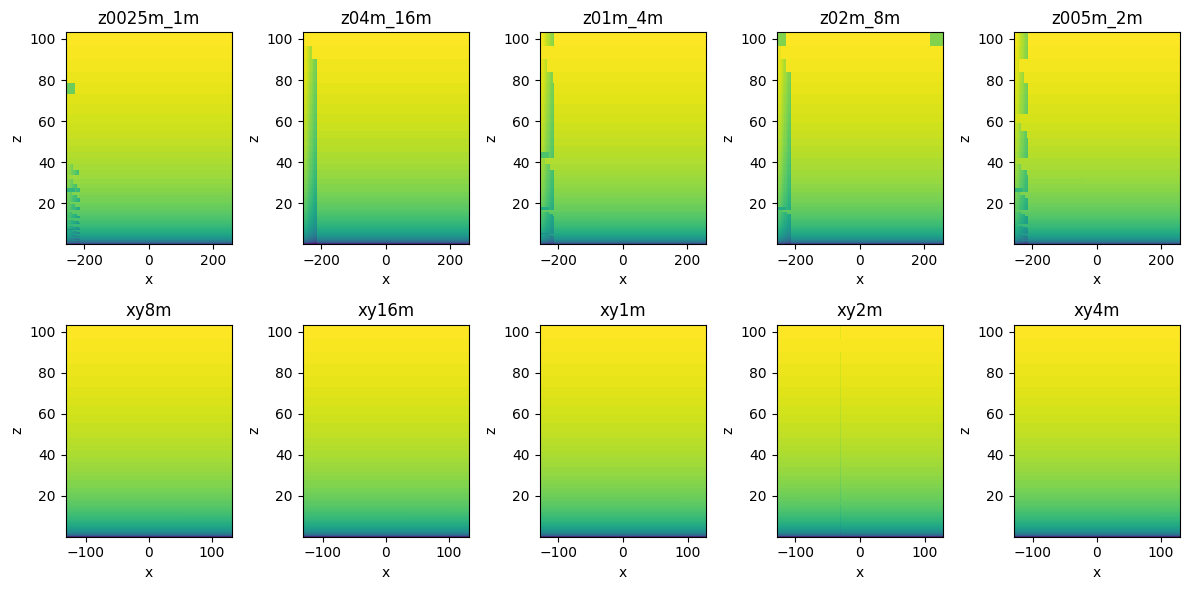

In [168]:
fig, ax = plt.subplots(2, 5, figsize=(12, 6))

i, j = 0, 0
for key in filenames.keys():
    if key.startswith('z'):
        cb = wind[key].ds.isel(y=10).U.plot(x='x', y='z', ax=ax[0, i])
        cb.colorbar.remove()
        ax[0, i].set_title(key)
        i += 1
    else:
        cb = wind[key].ds.isel(y=10).U.plot(x='x', y='z', ax=ax[1, j])
        cb.colorbar.remove()
        ax[1, j].set_title(key)
        j += 1
plt.tight_layout()

In [79]:
shots = ["Driver", "3-wood", "5-wood", "Hybrid", "4 Iron", "5 Iron", "6 Iron", "7 Iron", "8 Iron", "9 Iron", "PW"]
# Define a helper function for a single run to be used in parallel processing
def simulate_single_shot(shot_type, wind, solver='rk45', rotation=0):
    # Re-initialize or pass objects safely inside the worker
    traj = PGA(shot_type, wind=wind, orientation=rotation)
    traj.P0 = get_rotated_geometry(rotation)

    traj.solve(solver)

    return traj.p[-1][:2]

In [134]:
landing_points = {key: [] for key in filenames.keys()}

angles = np.arange(0, 360, 10)

for key in filenames.keys():
    results = Parallel(n_jobs=-1)(delayed(simulate_single_shot)(shot, wind=wind[key], rotation=angle) for shot in shots for angle in angles)

    landing_points[key] = np.array(results)

In [99]:
plot_keys = ['xy2m', 'xy4m', 'xy8m', 'xy16m', 'z005m_2m', 'z01m_4m', 'z02m_8m', 'z04m_16m']

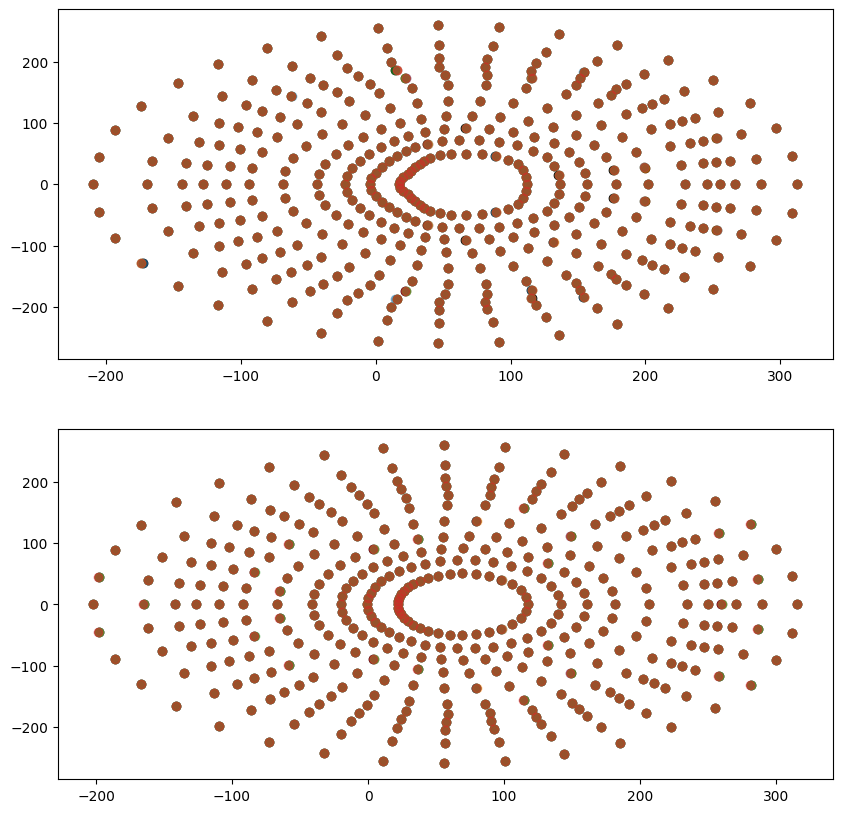

In [135]:
fig, ax = plt.subplots(2,1,figsize=(10, 10))

ref_z = landing_points['z0025m_1m']
ref_xy = landing_points['xy1m']

ax[0].scatter(ref_xy[:, 0], ref_xy[:, 1], label='Reference', color='black')
ax[1].scatter(ref_z[:, 0], ref_z[:, 1], label='Reference', color='black')
for key in plot_keys:
    if key.startswith('xy'):
        ax[0].scatter(landing_points[key][:, 0], landing_points[key][:, 1], label=key, alpha=0.5)
    else:
        ax[1].scatter(landing_points[key][:, 0], landing_points[key][:, 1], label=key, alpha=0.5)

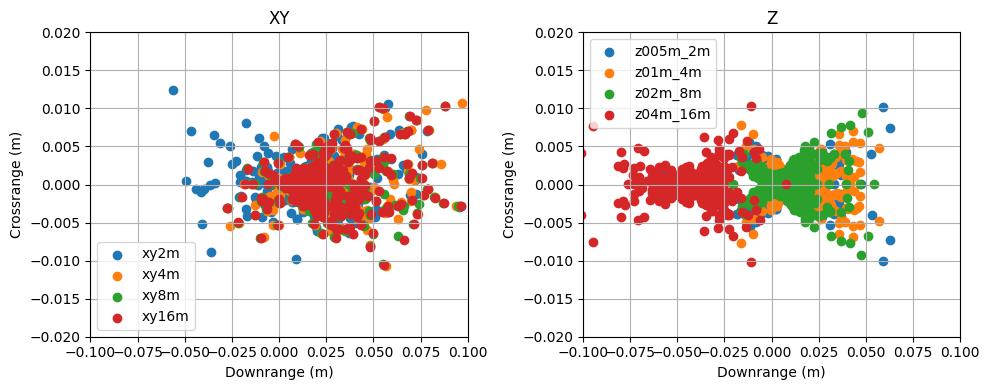

In [141]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ref_z = landing_points['z0025m_1m']
ref_xy = landing_points['xy1m']

for key in plot_keys:
    points = landing_points[key]
    if key.startswith('z'):
        ax[1].scatter(points[:, 0] - ref_z[:, 0], points[:, 1] - ref_z[:, 1], label=key)
    else:
        ax[0].scatter(points[:, 0] - ref_xy[:, 0], points[:, 1] - ref_xy[:, 1], label=key)

for i in range(2):
    ax[i].grid()
    ax[i].legend()
    ax[i].set_xlabel('Downrange (m)')
    ax[i].set_ylabel('Crossrange (m)')
ax[0].set_xlim(-.1, .1)
ax[0].set_ylim(-.02, .02)
ax[1].set_xlim(-.1, .1)
ax[1].set_ylim(-.02, .02)
ax[0].set_title('XY')
ax[1].set_title('Z')
plt.tight_layout()
plt.show()

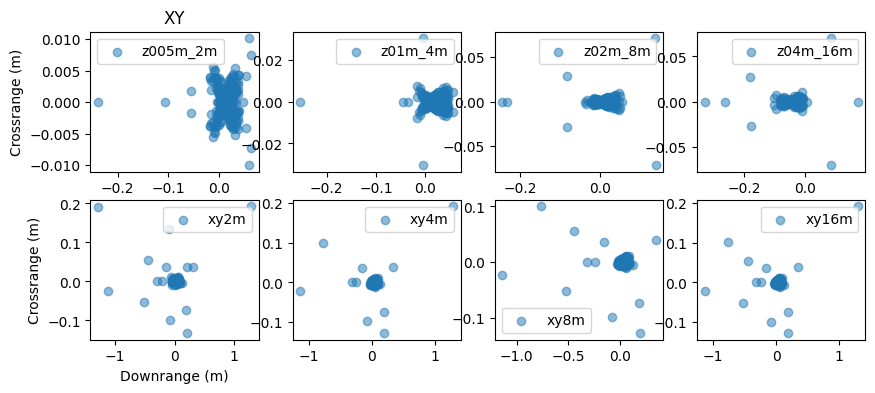

In [138]:
fig, ax = plt.subplots(2, 4, figsize=(10, 4))

ref_z = landing_points['z0025m_1m']
ref_xy = landing_points['xy1m']
i, j = 0, 0
for key in plot_keys:
    points = landing_points[key]
    if key.startswith('z'):
        ax[0, i].scatter(points[:, 0] - ref_z[:, 0], points[:, 1] - ref_z[:, 1], label=key, alpha=0.5)
        ax[0, i].legend()
        i += 1
    else:
        ax[1, j].scatter(points[:, 0] - ref_xy[:, 0], points[:, 1] - ref_xy[:, 1], label=key, alpha=0.5)
        ax[1, j].legend()
        j += 1
ax[0, 0].set_xlabel('Downrange (m)')
ax[0, 0].set_ylabel('Crossrange (m)')
ax[0, 0].set_title('XY')
ax[1, 0].set_xlabel('Downrange (m)')
ax[1, 0].set_ylabel('Crossrange (m)')
plt.show()

In [139]:
mean_distances = {key: None for key in plot_keys}
for key in plot_keys:
    ref_point = ref_z if key.startswith('z') else ref_xy
    mean_value = np.linalg.norm(landing_points[key] - ref_point, axis=1).mean()
    mean_distances[key] = mean_value

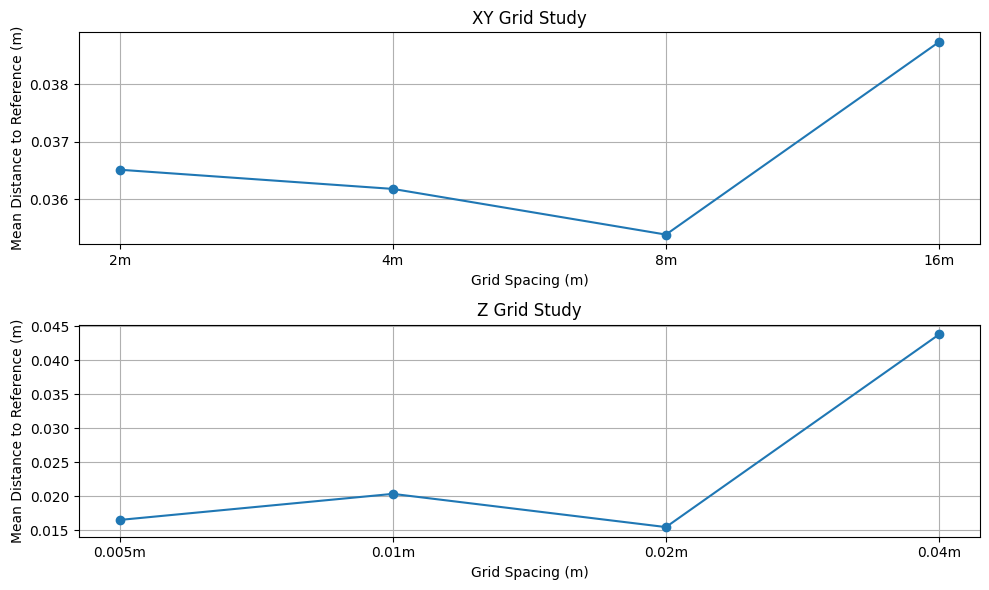

In [169]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot([mean_distances[key] for key in plot_keys if key.startswith('xy')], marker='o')
ax[1].plot([mean_distances[key] for key in plot_keys if key.startswith('z')], marker='o')

ax[0].grid()
ax[1].grid()
ax[0].set_xticks(range(4))
ax[1].set_xticks(range(4))
ax[0].set_xticklabels(['2m', '4m', '8m', '16m'])
ax[1].set_xticklabels(['0.005m', '0.01m', '0.02m', '0.04m'])
ax[0].set_xlabel('Grid Spacing (m)')
ax[0].set_ylabel('Mean Distance to Reference (m)')
ax[0].set_title('XY Grid Study')
ax[1].set_xlabel('Grid Spacing (m)')
ax[1].set_ylabel('Mean Distance to Reference (m)')
ax[1].set_title('Z Grid Study')
plt.tight_layout()
plt.show()